In [1]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [2]:
file_path = 'time_series_60min_singleindex.csv'

countries = ["CZ", "DE", "AT", "PL"]

target_columns = ["utc_timestamp"]
for c in countries:
    target_columns += [
        f"{c}_load_actual_entsoe_transparency",
        f"{c}_solar_generation_actual",
        f"{c}_wind_onshore_generation_actual"
    ]

df = pd.read_csv(file_path, usecols=target_columns, index_col=0, parse_dates=True)
df.index = df.index.tz_localize(None)

df_2019 = df.loc['2019-01-01':'2019-12-31'].copy().ffill().bfill().fillna(0)

# --- TECH DATA ---
def annuity(n, r):
    if r > 0:        
        return r / (1 - 1/(1+r)**n)
    else:
        return 1 / n

discount_rate = 0.07

# Gas marginal cost calculation
# Source: #https://www.sciencedirect.com/science/article/abs/pii/S036054421831288X?fr=RR-2&ref=pdf_download&rr=9ea337d92f634f62
fuel_cost_gas = 21.6 
vom_gas = 3.0        

# Hormuz blockade scenario: 70% increase in gas price
# Source: https://www.euronews.com/business/2026/03/05/iran-war-how-exposed-are-european-economies
# Source: https://www.euronews.com/my-europe/2026/03/31/strait-of-hormuz-shutdown-what-implications-for-europe-for-how-long-and-how-high-can-price
gas_reserve_factor = 0.216
gas_price_shock = 1.70  # 70% increase
fuel_cost_gas_hormuz = fuel_cost_gas * gas_price_shock  # 21.6 * 1.70 = 36.7 €/MWh

gas_marginal = (fuel_cost_gas_hormuz / 0.39) + vom_gas # 0.39 from gas efficiency

# Costs and parameters for each technology
# Source: #https://www.diw.de/documents/publikationen/73/diw_01.c.424566.de/diw_datadoc_2013-068.pdf
# Source: https://www.woodwayenergy.com/natural-gas-efficiency-in-power-generation/
tech_data = {
    'solar':       {'inv': 750000,  'fom': 0.03, 'life': 25, 'marg': 0.01,          'eff': 1.00,                            'color': "#f1c40f"},
    'wind':        {'inv': 1240000, 'fom': 0.03, 'life': 25, 'marg': 0.01,          'eff': 1.00,                            'color': "#3498db"},
    'nuclear':     {'inv': 6000000, 'fom': 0.025,'life': 40, 'marg': 11.5,          'eff': 1.00, 'avail': 0.9,              'color': "#e74c3c"},
    'coal':        {'inv': 1300000, 'fom': 0.02, 'life': 40, 'marg': 51.0,          'eff': 0.33, 'avail': 1.0, 'co2': 0.34, 'color': "#7f8c8d"},
    'gas':         {'inv': 400000,  'fom': 0.04, 'life': 30, 'marg': gas_marginal,  'eff': 0.39, 'avail': 1.0, 'co2': 0.19, 'color': "#e67e22"}
}

# --- STORAGE: BATTERY FOR PL AND AT ---

storage_data = {
    'battery': {
        'inv': 600000,      # EUR/MW for 4h system
        'fom': 0.02,
        'life': 15,
        'eff_store': 0.95,
        'eff_dispatch': 0.95,
        'max_hours': 4,
        'color': "#2ecc71",
    }
}

# Installed capacities of solar and wind of each country for CF scaling
# Source: #https://transparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YCZ-CEPS-----N%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%5B%222019%22%2C%222019%22%5D%2C%22tz%22%3A%22CET%22%7D
installed = {
    "CZ": {"solar": 2049,   "wind": 316},
    "DE": {"solar": 45435,  "wind": 52946},
    "PL": {"solar": 430,    "wind": 5808},
    "AT": {"solar": 1193,   "wind": 3035},
} 

# Capacity factors of solar and wind of each country
for c in countries:
    df_2019[f"{c}_solar_cf"] = (
        df_2019[f"{c}_solar_generation_actual"] / installed[c]["solar"]
    ).clip(0, 1)

    df_2019[f"{c}_wind_cf"] = (
        df_2019[f"{c}_wind_onshore_generation_actual"] / installed[c]["wind"]
    ).clip(0, 1)

In [3]:
# --- NETWORK MODEL ---
n = pypsa.Network()
n.set_snapshots(df_2019.index)

# Buses
n.add("Bus", countries)

# Gas buses
for c in countries:
    n.add("Bus", f"{c}_gas")

# Carriers
for tech, d in tech_data.items():
    n.add("Carrier", tech, co2_emissions=d.get("co2", 0), color=d["color"])

n.add("Carrier", "ch4", co2_emissions=0.19, color="#a75610") # Carrier for CH4 gas supply
n.add("Carrier", "battery", color=storage_data["battery"]["color"]) # Carrier for battery storage

# --- LOADS ---
for c in countries:
    n.add("Load", f"{c}_load",
          bus=c,
          p_set=df_2019[f"{c}_load_actual_entsoe_transparency"])

# --- GENERATORS ---
for c in countries:
    for tech, d in tech_data.items():

        if tech == "gas":
            continue  # Gas will be added as a separate generator on DE gas bus

        name = f"{c}_{tech}"

        # Costs
        capital_cost = d['inv'] * (annuity(d['life'], discount_rate) + d['fom'])

        # Marginal cost + CF
        if  tech == "wind":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_wind_cf"]
            efficiency = d["eff"]

        elif tech == "solar":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_solar_cf"]
            efficiency = d["eff"]

        else:
            marginal_cost = d["marg"]
            p_max_pu = d["avail"]
            efficiency = d["eff"]

        n.add("Generator",
              name,
              bus = c,
              carrier = tech,
              p_nom_extendable = True,
              capital_cost = capital_cost,
              marginal_cost = marginal_cost,
              efficiency = efficiency,
              p_max_pu = p_max_pu)

# Gas supply for DE gas bus        
n.add("Generator", "DE_gas_supply",
        bus = "DE_gas",
        carrier = "ch4",
        p_nom_extendable = True,
        capital_cost = 400000 * (annuity(30, discount_rate) + 0.04),
        marginal_cost = gas_marginal,
        efficiency = 0.39, # Gas supply is modelled as a commodity supply, not a generator, so efficiency is 1.
        p_max_pu = gas_reserve_factor)

for c in countries:
    d = storage_data["battery"]
    capital_cost = d["inv"] * (annuity(d["life"], discount_rate) + d["fom"])

    n.add(
        "StorageUnit",
        name=f"{c}_battery",
        bus=c,
        p_nom_extendable=True,
        capital_cost=capital_cost,
        max_hours=d["max_hours"],
        efficiency_store=d["eff_store"],
        efficiency_dispatch=d["eff_dispatch"],
        cyclic_state_of_charge=True,
        carrier="battery",
    )


# --- TRANSMISSION ---
# Capacities based on 2026 max physical flows between the countries
# Source: #https://transparency.entsoe.eu/transmission/physicalFlows?appState=%7B%22sa%22%3A%5B%22CTY%7C10YCZ-CEPS-----N%22%5D%2C%22st%22%3A%22CTY%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%222026-04-01%22%2C%22tz%22%3A%22CET%22%7D
lines = [
    ("CZ", "DE", 3500), # max: 3449
    ("CZ", "AT", 2500), # max: 2390
    ("CZ", "PL", 2500), # max: 2487
    ("DE", "PL", 3000), # max: 2820
]

# Add electrical lines
for b0, b1, cap in lines:
    n.add("Line", f"{b0}-{b1}", 
          bus0=b0, 
          bus1=b1, 
          x=1, 
          s_nom=cap)

# Add gas pipelines
gas_pipe_connections = [
    ("DE", c) for c in countries if c != "DE"
]

for b0, b1 in gas_pipe_connections:
    n.add("Link", f"{b0}-{b1}_gas_pipe",
          bus0=f"{b0}_gas",
          bus1=f"{b1}_gas",
          p_nom_extendable=True,
          p_min_pu=-1,
          efficiency=0.98)

# Add gas-to-power conversion links    
for c in countries:
    n.add("Link", f"{c}_gas_to_power",
          bus0=f"{c}_gas",
          bus1=c,
          p_nom_extendable=True,
          marginal_cost=0) # Marginal cost is 0 because fuel cost is accounted in the gas supply generator

# --- OPTIMIZATION ---
n.optimize(solver_name="gurobi")

C:\Users\Bagus\AppData\Local\Temp\ipykernel_28044\189123477.py:131: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['CZ', 'DE', 'AT', 'PL', 'CZ_gas', 'DE_gas', 'AT_gas', 'PL_gas'], dtype='str', name='name')
Index(['DE-CZ_gas_pipe', 'DE-AT_gas_pipe', 'DE-PL_gas_pipe', 'CZ_gas_to_power',
       'DE_gas_to_power', 'AT_gas_to_power', 'PL_gas_to_power'],
      dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 82.29it/s]
INFO:linopy.io: Writing time: 1.74s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2794134


INFO:gurobipy:Set parameter LicenseID to value 2794134


...

Solved in 146832 iterations and 15.51 seconds (7.78 work units)


INFO:gurobipy:Solved in 146832 iterations and 15.51 seconds (7.78 work units)


Optimal objective  5.526066399e+10


INFO:gurobipy:Optimal objective  5.526066399e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 350428 primals, 814708 duals
Objective: 5.53e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

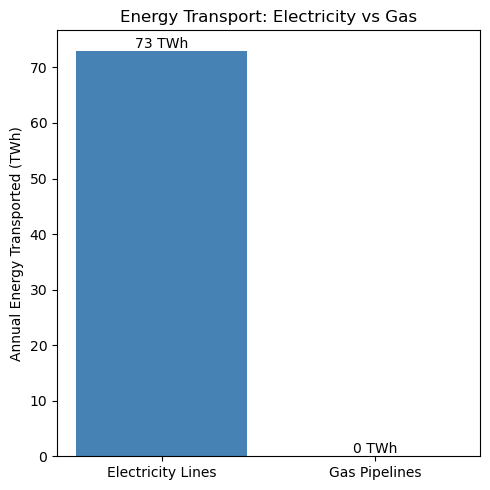

Electricity lines : 73 TWh
Gas pipelines     : 0 TWh


In [4]:
gas_pipes   = [l for l in n.links.index if l.endswith("_gas_pipe")]
gas_to_pow  = [l for l in n.links.index if l.endswith("_gas_to_power")]
elec_lines  = list(n.lines.index)

elec_flow_TWh = (n.lines_t.p0.abs()).sum().sum() / 1e6
gas_flow_TWh  = (n.links_t.p0[gas_pipes].abs()).sum().sum() / 1e6

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(["Electricity Lines", "Gas Pipelines"],
              [elec_flow_TWh, gas_flow_TWh],
              color=["steelblue", "#e67e22"])

ax.bar_label(bars, fmt="%.0f TWh", padding=0)
ax.set_ylabel("Annual Energy Transported (TWh)")
ax.set_title("Energy Transport: Electricity vs Gas")
plt.tight_layout()
plt.show()

print(f"Electricity lines : {elec_flow_TWh:,.0f} TWh")
print(f"Gas pipelines     : {gas_flow_TWh:,.0f} TWh")

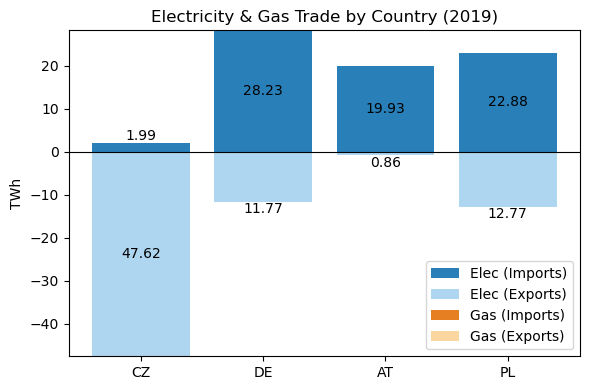

In [5]:
imports_elec = {c: 0 for c in countries}
exports_elec = {c: 0 for c in countries}
imports_gas  = {c: 0 for c in countries}
exports_gas  = {c: 0 for c in countries}

# Electricity lines
for line in n.lines.index:
    b0 = n.lines.at[line, "bus0"]
    b1 = n.lines.at[line, "bus1"]
    flow = n.lines_t.p0[line]

    exports_elec[b0] += flow.clip(lower=0).sum()
    imports_elec[b1] += flow.clip(lower=0).sum()
    exports_elec[b1] += (-flow).clip(lower=0).sum()
    imports_elec[b0] += (-flow).clip(lower=0).sum()

# Gas pipelines
gas_pipes = [l for l in n.links.index if l.endswith("_gas_pipe")]
for pipe in gas_pipes:
    b0 = n.links.at[pipe, "bus0"].replace("_gas", "")
    b1 = n.links.at[pipe, "bus1"].replace("_gas", "")
    flow = n.links_t.p0[pipe]

    exports_gas[b0] += flow.clip(lower=0).sum()
    imports_gas[b1] += flow.clip(lower=0).sum()
    exports_gas[b1] += (-flow).clip(lower=0).sum()
    imports_gas[b0] += (-flow).clip(lower=0).sum()

imports_elec =  pd.Series(imports_elec) / 1e6
exports_elec = -pd.Series(exports_elec) / 1e6  # negative
imports_gas  =  pd.Series(imports_gas)  / 1e6
exports_gas  = -pd.Series(exports_gas)  / 1e6  # negative

x = range(len(countries))
width = 0.8

fig, ax = plt.subplots(figsize=(6, 4))

bars_i_e = ax.bar(x, imports_elec, width, color="#2980b9", label="Elec (Imports)")
bars_e_e = ax.bar(x, exports_elec, width, color="#aed6f1", label="Elec (Exports)")

bars_i_g = ax.bar(x, imports_gas,  width, bottom=imports_elec,
                  color="#e67e22", label="Gas (Imports)")
bars_e_g = ax.bar(x, exports_gas,  width, bottom=exports_elec,
                  color="#fad7a0", label="Gas (Exports)")

MIN_LABEL = 15

for container, color in [(bars_i_e, "white"), (bars_i_g, "black"),
                          (bars_e_e, "white"), (bars_e_g, "black")]:
    for bar in container:
        height = bar.get_height()
        if abs(height) > 0.05:
            if abs(height) < MIN_LABEL:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height + (0.05 if height > 0 else -0.05),
                    f"{abs(height):.2f}",
                    ha="center", va="bottom" if height > 0 else "top",
                )
            else:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{abs(height):.2f}",
                    ha="center", va="center",
                )

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.set_ylabel("TWh")
ax.set_title("Electricity & Gas Trade by Country (2019)")
ax.legend()
plt.tight_layout()
plt.show()

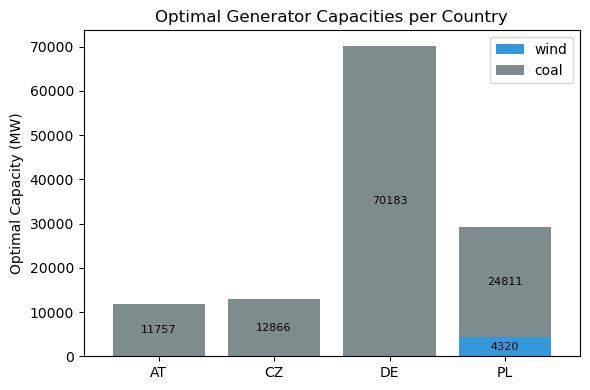

In [6]:
gen_caps = n.generators[["bus", "carrier", "p_nom_opt"]].copy()
gen_caps = gen_caps[gen_caps["p_nom_opt"] > 1]

# Add gas-to-power link capacities
gas_to_pow = [l for l in n.links.index if l.endswith("_gas_to_power")]
g2p_caps = pd.DataFrame({
    "bus": [n.links.at[l, "bus1"] for l in gas_to_pow],
    "carrier": "gas",
    "p_nom_opt": [n.links.at[l, "p_nom_opt"] for l in gas_to_pow]
}, index=gas_to_pow)
g2p_caps = g2p_caps[g2p_caps["p_nom_opt"] > 1]

gen_caps = pd.concat([gen_caps, g2p_caps])

gen_caps["bus"] = gen_caps["bus"].str.replace("_gas", "")

pivot = gen_caps.pivot_table(index="bus", columns="carrier", values="p_nom_opt", aggfunc="sum")

# Reorder columns
desired_order = ["nuclear", "solar", "ch4", "gas", "wind", "coal"]
ordered_cols = [c for c in desired_order if c in pivot.columns]

pivot = pivot[ordered_cols]

fig, ax = plt.subplots(figsize=(6, 4))
pivot.plot.bar(ax=ax, stacked=True,
               color=[n.carriers.at[c, "color"] for c in pivot.columns],
               width=0.8)

MIN_SEGMENT = 3000  

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 1:
            y = bar.get_y() + height / 2
            # if segment is too small, push label above the bar
            if height < MIN_SEGMENT:
                y = bar.get_y() + height + 200
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f"{height:.0f}",
                ha="center", va="bottom" if height < MIN_SEGMENT else "center",
                fontsize=8
            )

ax.set_ylabel("Optimal Capacity (MW)")
ax.set_title("Optimal Generator Capacities per Country")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=0)

handles, labels = ax.get_legend_handles_labels()
labels = ["gas (to power)" if l == "gas" else l for l in labels]
ax.legend(handles, labels)

plt.tight_layout()
plt.show()

In [7]:
#Calculate baseline CO2 emissions

def calculate_system_emissions(n):
    """
    Calculates total system-wide CO2 emissions.

    The formula uses:
    - generator dispatch over time,
    - generator efficiency,
    - carrier-specific CO2 emissions,
    - snapshot weightings to annualize the result.
    """

    emissions = (
        n.generators_t.p
        .div(n.generators.efficiency, axis=1)
        .mul(n.generators.carrier.map(n.carriers.co2_emissions), axis=1)
        .mul(n.snapshot_weightings.generators, axis=0)
        .sum()
        .sum()
    )

    return emissions


baseline_emissions = calculate_system_emissions(n)

print(f"Baseline system-wide CO2 emissions: {baseline_emissions / 1e6:.2f} MtCO2/year")

# Select 50% of the baseline system-wide CO2 emissions
target_fraction = 0.50

co2_limit = baseline_emissions * target_fraction

print(f"Selected decarbonisation target: {target_fraction*100:.0f}% of baseline emissions")
print(f"CO2 allowance limit: {co2_limit / 1e6:.2f} MtCO2/year")

Baseline system-wide CO2 emissions: 801.40 MtCO2/year
Selected decarbonisation target: 50% of baseline emissions
CO2 allowance limit: 400.70 MtCO2/year


In [8]:
# Create a copy of the baseline interconnected network.
# This keeps the original baseline results unchanged.
try:
    n.model.solver_model = None
except AttributeError:
    pass

n2 = n.copy()

# Add the global CO2 constraint.
# The system is not allowed to emit more than the selected CO2 limit.
n2.add(
    "GlobalConstraint",
    "co2_limit_part_h",
    type="primary_energy",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=co2_limit
)

n2.optimize(solver_name="gurobi")

C:\Users\Bagus\AppData\Local\Temp\ipykernel_28044\1214080171.py:21: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['CZ', 'DE', 'AT', 'PL', 'CZ_gas', 'DE_gas', 'AT_gas', 'PL_gas'], dtype='str', name='name')
Index(['DE-CZ_gas_pipe', 'DE-AT_gas_pipe', 'DE-PL_gas_pipe', 'CZ_gas_to_power',
       'DE_gas_to_power', 'AT_gas_to_power', 'PL_gas_to_power'],
      dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 83.31it/s]
INFO:linopy.io: Writing time

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2794134


INFO:gurobipy:Set parameter LicenseID to value 2794134


...

Solved in 245264 iterations and 453.41 seconds (508.63 work units)


INFO:gurobipy:Solved in 245264 iterations and 453.41 seconds (508.63 work units)


Optimal objective  6.097448752e+10


INFO:gurobipy:Optimal objective  6.097448752e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 350428 primals, 814709 duals
Objective: 6.10e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

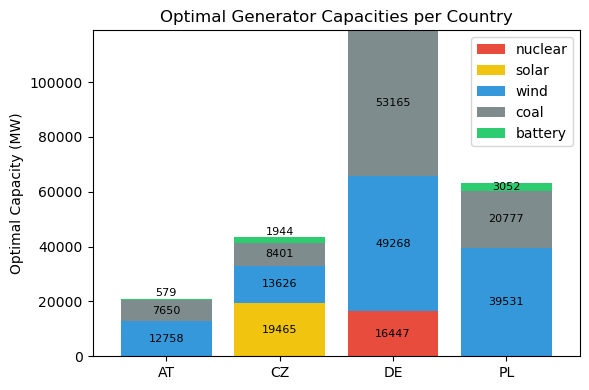

In [11]:
gen_caps = n2.generators[["bus", "carrier", "p_nom_opt"]].copy()
gen_caps = gen_caps[gen_caps["p_nom_opt"] > 1]

# Add gas-to-power link capacities
gas_to_pow = [l for l in n2.links.index if l.endswith("_gas_to_power")]
g2p_caps = pd.DataFrame({
    "bus": [n2.links.at[l, "bus1"] for l in gas_to_pow],
    "carrier": "gas",
    "p_nom_opt": [n2.links.at[l, "p_nom_opt"] for l in gas_to_pow]
}, index=gas_to_pow)
g2p_caps = g2p_caps[g2p_caps["p_nom_opt"] > 1]

gen_caps = pd.concat([gen_caps, g2p_caps])

# Add battery storage capacities
battery_units = [u for u in n2.storage_units.index if "battery" in u]
battery_caps = pd.DataFrame({
    "bus": [n2.storage_units.at[u, "bus"] for u in battery_units],
    "carrier": "battery",
    "p_nom_opt": [n2.storage_units.at[u, "p_nom_opt"] for u in battery_units]
}, index=battery_units)
battery_caps = battery_caps[battery_caps["p_nom_opt"] > 1]

gen_caps = pd.concat([gen_caps, battery_caps])

gen_caps["bus"] = gen_caps["bus"].str.replace("_gas", "")

pivot = gen_caps.pivot_table(index="bus", columns="carrier", values="p_nom_opt", aggfunc="sum")

# Reorder columns
desired_order = ["nuclear", "solar", "ch4", "gas", "wind", "coal", "battery"]
ordered_cols = [c for c in desired_order if c in pivot.columns]

pivot = pivot[ordered_cols]

fig, ax = plt.subplots(figsize=(6, 4))
pivot.plot.bar(ax=ax, stacked=True,
               color=[n2.carriers.at[c, "color"] for c in pivot.columns],
               width=0.8)

MIN_SEGMENT = 3000  

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 1:
            y = bar.get_y() + height / 2
            # if segment is too small, push label above the bar
            if height < MIN_SEGMENT:
                y = bar.get_y() + height + 200
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f"{height:.0f}",
                ha="center", va="bottom" if height < MIN_SEGMENT else "center",
                fontsize=8
            )

ax.set_ylabel("Optimal Capacity (MW)")
ax.set_title("Optimal Generator Capacities per Country")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=0)

handles, labels = ax.get_legend_handles_labels()
labels = ["gas (to power)" if l == "gas" else l for l in labels]
ax.legend(handles, labels)

plt.tight_layout()
plt.show()

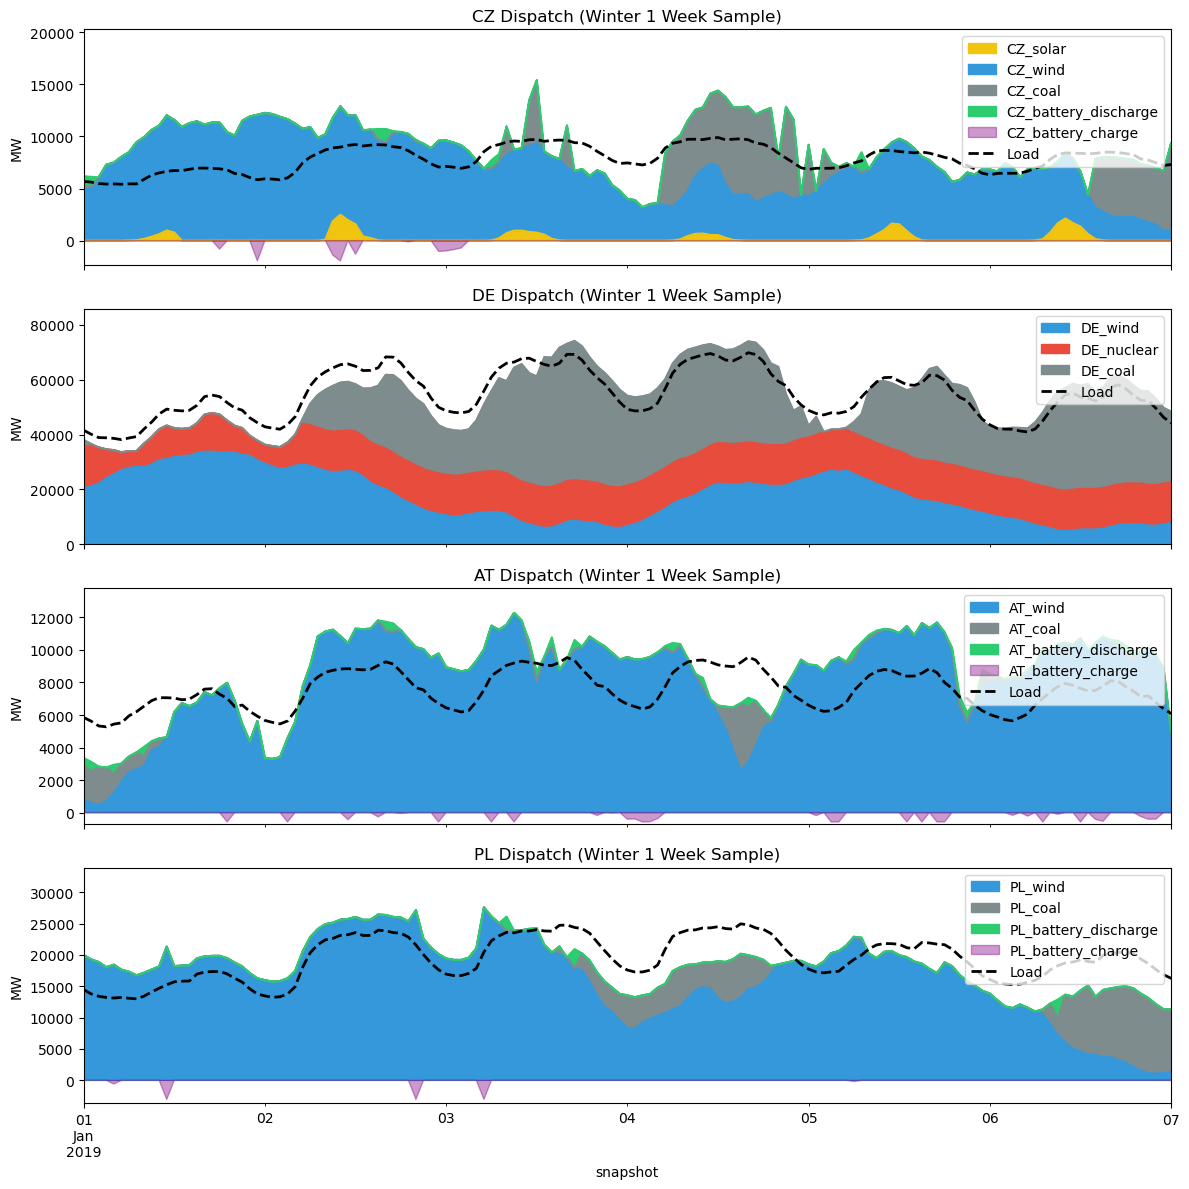

Discharge sum: 655628.1899119674
Charge sum: -726457.8281573046


In [ ]:
SIGNIFICANCE_THRESHOLD = 0.0

fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):
    ax = axes[i] if len(countries) > 1 else axes

    gens = [g for g in n2.generators.index if g.startswith(c)]
    gen_dispatch = n2.generators_t.p[gens]

    # Gas-to-power output
    gas_to_pow = f"{c}_gas_to_power"
    gas_dispatch = (
        -n2.links_t.p1[gas_to_pow]
        if gas_to_pow in n2.links.index
        else pd.Series(0, index=n2.snapshots)
    )

    # Battery
    battery_unit = f"{c}_battery"
    if battery_unit in n2.storage_units.index:
        p = n2.storage_units_t.p[battery_unit]

        battery_discharge = p.clip(lower=0)   # >= 0
        battery_charge = p.clip(upper=0)      # <= 0 (keep negative!)
    else:
        battery_discharge = pd.Series(0, index=n2.snapshots)
        battery_charge = pd.Series(0, index=n2.snapshots)

    # Total for filtering
    total = (
        gen_dispatch.sum().sum()
        + gas_dispatch.sum()
        + battery_discharge.sum()
        + (-battery_charge).sum()
    )

    significant_gens = [
        g for g in gens
        if gen_dispatch[g].sum() / total > SIGNIFICANCE_THRESHOLD
    ]

    # Build stacked dataframe (ONLY positive contributors)
    plot_df = gen_dispatch[significant_gens].copy()

    if gas_dispatch.sum() / total > SIGNIFICANCE_THRESHOLD:
        plot_df[f"{c}_gas_to_power"] = gas_dispatch

    if battery_discharge.sum() / total > SIGNIFICANCE_THRESHOLD:
        plot_df[f"{c}_battery_discharge"] = battery_discharge

    # Colors
    colors = [
        n2.carriers.at[n2.generators.at[g, "carrier"], "color"]
        for g in significant_gens
    ]

    if f"{c}_gas_to_power" in plot_df.columns:
        colors.append(tech_data["gas"]["color"])

    if f"{c}_battery_discharge" in plot_df.columns:
        colors.append(storage_data["battery"]["color"])

    # Plot generation + discharge
    plot_df.plot.area(ax=ax, color=colors)

    # Plot battery charging (negative)
    if battery_charge.abs().sum() > 0:
        ax.fill_between(
        battery_charge.index,
        battery_charge.values,
        0,
        color="purple",
        alpha=0.4,
        label=f"{c}_battery_charge",
        zorder=5
        )

    # Load
    n2.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Winter 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.set_ylim(battery_charge.min()*1.2, None)
    ax.legend(loc='upper right')

plt.xlim("2019-01-01", "2019-01-07")
plt.tight_layout()
plt.show()

print("Discharge sum:", battery_discharge.sum())
print("Charge sum:", battery_charge.sum())

In [21]:
print(f"Baseline system-wide CO2 emissions: {calculate_system_emissions(n) / 1e6:.2f} MtCO2/year")
print(f"Total System Cost: {n.objective/1e6:.2f} M€\n")

print(f"Baseline system-wide CO2 emissions: {calculate_system_emissions(n2) / 1e6:.2f} MtCO2/year")
print(f"Total System Cost: {n2.objective/1e6:.2f} M€\n")

Baseline system-wide CO2 emissions: 801.40 MtCO2/year
Total System Cost: 55260.66 M€

Baseline system-wide CO2 emissions: 400.70 MtCO2/year
Total System Cost: 60974.49 M€

